# ?? Task 3: TalentMatch ML ? Resume Screening & Candidate Ranking System
### Track: Machine Learning (`ML`) | Internship ID: `FIT/AUG26/ML10465` | Repository: `FUTURE_ML_03`

---
### **Project Overview & Objectives**
In modern technical recruiting, recruiters manually parse hundreds of heterogeneous resumes to identify qualified candidates, risking cognitive fatigue, unconscious bias, and inconsistent skill evaluation.

**TalentMatch ML** is a prototype recruiter decision-support system that provides:
1. **Multi-Format Ingestion**: Parsers for `.pdf`, `.docx`, and `.txt` candidate documents.
2. **PII Anonymization & Fairness**: Automatic masking of candidate names, emails, phone numbers, and social profiles prior to scoring.
3. **Controlled Technical Skill Taxonomy**: 200+ canonical competencies across 5 domains with alias resolution.
4. **4-Tier Hybrid Scoring Architecture**:
   - Hard Skill Overlap (40%)
   - Dense Semantic Similarity via `SentenceTransformer('all-MiniLM-L6-v2')` (30%)
   - TF-IDF Lexical Cosine Similarity (20%)
   - Experience & Education Alignment (10%)
5. **Skill Gap Diagnostics & Explainability**: Identification of matched required skills, missing required skills, and preferred bonuses.

---
### **Dataset Provenance & Disclosure**:
- **Corpus Nature**: Controlled, synthetic benchmark corpus representing 8 distinct engineering profiles across PDF, DOCX, and TXT formats.
- **Purpose**: Demonstrates end-to-end algorithmic matching logic, PII masking, and multi-tier scoring pipeline functionality in a prototype recruiter decision-support context.


In [1]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
%matplotlib inline

sys.path.append(os.path.abspath('..'))

from src.data_generator import generate_sample_resumes, generate_sample_job_descriptions
from src.parser import parse_resume, anonymize_resume_text
from src.taxonomy import get_all_canonical_skills, SKILL_TAXONOMY
from src.matcher import TalentMatcher

print("? TalentMatch ML environment loaded. Python version:", sys.version.split()[0])

? TalentMatch ML environment loaded. Python version: 3.12.5


## 1. Resume Ingestion & Multi-Format Parsing

In [2]:
resumes_dir = os.path.join('..', 'data', 'resumes')
jds_dir = os.path.join('..', 'data', 'job_descriptions')

generate_sample_resumes(resumes_dir)
generate_sample_job_descriptions(jds_dir)

resume_files = [os.path.join(resumes_dir, f) for f in os.listdir(resumes_dir) if f.endswith(('.docx', '.txt', '.pdf'))]
candidate_profiles = [parse_resume(f) for f in resume_files]

print(f"Total Candidate Resumes Ingested: {len(candidate_profiles)}")
for c in candidate_profiles:
    print(f"-> {c['candidate_id']:<38} | Format: {os.path.splitext(c['filepath'])[1]} | Exp: {c['experience_years']} yrs | Edu: {c['education_level']}")

[DataGenerator] Sample candidate corpus created across PDF, DOCX, and TXT formats in ..\data\resumes
[DataGenerator] 3 structured Job Descriptions saved to ..\data\job_descriptions


Total Candidate Resumes Ingested: 8
-> candidate_01_lead_ml_engineer          | Format: .docx | Exp: 6.5 yrs | Edu: Master's Degree
-> candidate_02_data_scientist            | Format: .txt | Exp: 4.0 yrs | Edu: Master's Degree
-> candidate_03_junior_ml_intern          | Format: .pdf | Exp: 1.0 yrs | Edu: Bachelor's Degree
-> candidate_04_fullstack_lead            | Format: .docx | Exp: 7.0 yrs | Edu: Bachelor's Degree
-> candidate_05_frontend_dev              | Format: .txt | Exp: 3.0 yrs | Edu: Bachelor's Degree
-> candidate_06_devops_cloud_architect    | Format: .docx | Exp: 8.0 yrs | Edu: Bachelor's Degree
-> candidate_07_bi_data_analyst           | Format: .txt | Exp: 4.5 yrs | Edu: Bachelor's Degree
-> candidate_08_java_backend_dev          | Format: .txt | Exp: 5.5 yrs | Edu: Bachelor's Degree


## 2. PII Anonymization & Fairness Safeguard

In [3]:
sample_candidate = candidate_profiles[0]
print("--- RAW RESUME TEXT SAMPLE ---")
print(sample_candidate["raw_text"][:350])

print("\n--- ANONYMIZED TEXT (PASSED TO SCORING ENGINE) ---")
print(sample_candidate["anonymized_text"][:350])

--- RAW RESUME TEXT SAMPLE ---
Alex Rivera — Senior Machine Learning & MLOps Engineer
Email: alex.rivera.ml@example.com | Phone: (555) 234-5678 | GitHub: github.com/arivera-ml
Professional Summary
Senior Machine Learning Engineer with 6.5 years of experience building, training, and deploying large-scale deep learning models, LLM pipelines, and automated MLOps infrastructure in c

--- ANONYMIZED TEXT (PASSED TO SCORING ENGINE) ---
[NAME_MASKED] — Senior Machine Learning & MLOps Engineer
Email: [EMAIL_MASKED] | Phone: [PHONE_MASKED] | GitHub: [SOCIAL_PROFILE_MASKED]
[NAME_MASKED] Senior Machine Learning Engineer with 6.5 years of experience building, training, and deploying large-scale deep learning models, LLM pipelines, and automated MLOps infrastructure in cloud environmen


## 3. Controlled Technical Skill Taxonomy (200+ Competencies)

In [4]:
canonical_skills = get_all_canonical_skills()
print(f"Total Canonical Skills in Taxonomy: {len(canonical_skills)}")
for domain, skills in SKILL_TAXONOMY.items():
    print(f"  ? {domain} ({len(skills)} skills): {skills[:6]} ...")

Total Canonical Skills in Taxonomy: 107
  ? Machine Learning & AI (24 skills): ['machine learning', 'deep learning', 'natural language processing', 'computer vision', 'scikit-learn', 'tensorflow'] ...
  ? Data Engineering & Databases (23 skills): ['python', 'sql', 'postgresql', 'mysql', 'mongodb', 'redis'] ...
  ? Cloud & DevOps (22 skills): ['amazon web services', 'aws', 'google cloud platform', 'gcp', 'microsoft azure', 'docker'] ...
  ? Software Engineering & Web (24 skills): ['javascript', 'typescript', 'react', 'next.js', 'node.js', 'express'] ...
  ? Analytics & BI (14 skills): ['pandas', 'numpy', 'matplotlib', 'seaborn', 'tableau', 'power bi'] ...


## 4. Multi-Tier Hybrid Candidate Scoring & Ranking

In [5]:
jd_path = os.path.join(jds_dir, "job_senior_ml_engineer.json")
with open(jd_path, "r", encoding="utf-8") as f:
    job_description = json.load(f)

print(f"Target Role: {job_description['title']}")
print(f"Required Skills ({len(job_description['required_skills'])}): {job_description['required_skills']}")
print(f"Preferred Skills ({len(job_description['preferred_skills'])}): {job_description['preferred_skills']}")

matcher = TalentMatcher(use_dense_embeddings=True)
rankings_df = matcher.rank_candidates(candidate_profiles, job_description)

print("\nCandidate Screening Leaderboard:")
display(rankings_df[["Rank", "candidate_id", "composite_score", "skill_score_pct", "semantic_similarity_pct", "lexical_similarity_pct", "exp_edu_fit_pct", "gap_severity"]])

Target Role: Senior Machine Learning Engineer (NLP & MLOps)
Required Skills (8): ['python', 'pytorch', 'scikit-learn', 'machine learning', 'natural language processing', 'docker', 'aws', 'model deployment']
Preferred Skills (6): ['transformers', 'huggingface', 'kubernetes', 'mlops', 'langchain', 'sql']


[TalentMatcher] Loaded SentenceTransformer (all-MiniLM-L6-v2) for dense semantic scoring.



Candidate Screening Leaderboard:


,Rank,candidate_id,composite_score,skill_score_pct,semantic_similarity_pct,lexical_similarity_pct,exp_edu_fit_pct,gap_severity
0,1,candidate_01_lead_ml_engineer,76.03,100.0,72.2,22.7,98.5,Low
1,2,candidate_03_junior_ml_intern,43.90,60.0,43.1,13.3,43.0,Moderate
2,3,candidate_02_data_scientist,39.25,43.3,35.8,6.7,98.5,Moderate
3,4,candidate_06_devops_cloud_architect,39.03,33.3,49.3,6.8,95.5,High
4,5,candidate_04_fullstack_lead,30.28,20.0,39.7,4.1,95.5,High
5,6,candidate_08_java_backend_dev,24.79,13.3,30.7,3.4,95.5,High
6,7,candidate_07_bi_data_analyst,23.25,13.3,26.9,1.5,95.5,High
7,8,candidate_05_frontend_dev,14.76,0.0,22.0,1.9,78.0,High


## 5. Recruiter Decision Support & Skill Gap Diagnostics

In [6]:
for idx, row in rankings_df.iterrows():
    print(f"Rank {row['Rank']}: {row['candidate_id']} (Composite Score: {row['composite_score']}%)")
    print(f"   ? Recommendation: {row['recommendation']}")
    print(f"   ? Matched Required: {row['matched_required']}")
    print(f"   ? Missing Required: {row['missing_required']}")
    print(f"   ? Matched Preferred: {row['matched_preferred']}\n")

Rank 1: candidate_01_lead_ml_engineer (Composite Score: 76.03%)
   ? Recommendation: Strong overall match. All mandatory competencies satisfied. Recommended for recruiter review and technical screening.
   ? Matched Required: ['amazon web services', 'docker', 'machine learning', 'model deployment', 'natural language processing', 'python', 'pytorch', 'scikit-learn']
   ? Missing Required: []
   ? Matched Preferred: ['huggingface', 'kubernetes', 'langchain', 'mlops', 'sql', 'transformers']

Rank 2: candidate_03_junior_ml_intern (Composite Score: 43.9%)
   ? Recommendation: Moderate match. Review candidate profile and skill gaps with hiring manager.
   ? Matched Required: ['docker', 'machine learning', 'model deployment', 'python', 'pytorch', 'scikit-learn']
   ? Missing Required: ['amazon web services', 'natural language processing']
   ? Matched Preferred: []

Rank 3: candidate_02_data_scientist (Composite Score: 39.25%)
   ? Recommendation: High technical gap. Candidate lacks several c

## 6. Visual Candidate Ranking Breakdown

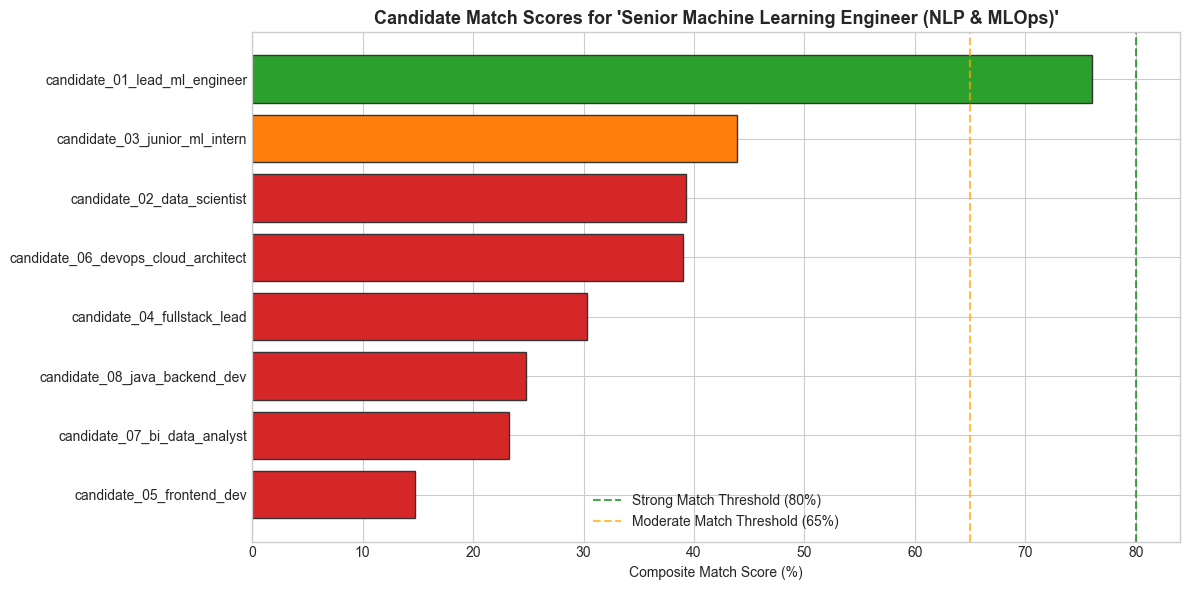

In [7]:
plt.figure(figsize=(12, 6))
colors = ["#2ca02c" if s >= 70 else "#ff7f0e" if s >= 40 else "#d62728" for s in rankings_df["composite_score"]]
plt.barh(rankings_df["candidate_id"], rankings_df["composite_score"], color=colors, edgecolor="#333333")
plt.axvline(80, color="green", linestyle="--", alpha=0.7, label="Strong Match Threshold (80%)")
plt.axvline(65, color="orange", linestyle="--", alpha=0.7, label="Moderate Match Threshold (65%)")
plt.gca().invert_yaxis()
plt.title(f"Candidate Match Scores for '{job_description['title']}'", fontsize=13, fontweight="bold")
plt.xlabel("Composite Match Score (%)")
plt.legend()
plt.tight_layout()
plt.show()